# RNN on a Time Series
In this project we're using data from the Federal Reserve Economic Database (FRED) concerning Sales of Beer, Wine, and Distilled Alcoholic Beverages in millions of dollars from January 1992 to January 2019 (325 records).

Data source: https://fred.stlouisfed.org/series/S4248SM144NCEN

In [445]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# This relates to plotting datetime values with matplotlib:
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

In [446]:
df = pd.read_csv('Data/TimeSeriesData/Alcohol_Sales.csv', index_col=0, parse_dates=True)

In [447]:
df

,S4248SM144NCEN
DATE,
1992-01-01,3459
1992-02-01,3458
1992-03-01,4002
1992-04-01,4564
1992-05-01,4221
...,...
2018-09-01,12396
2018-10-01,13914
2018-11-01,14174


In [448]:
len(df)

325

In [449]:
df = df.dropna()

In [450]:
len(df)

325

<Axes: xlabel='DATE'>

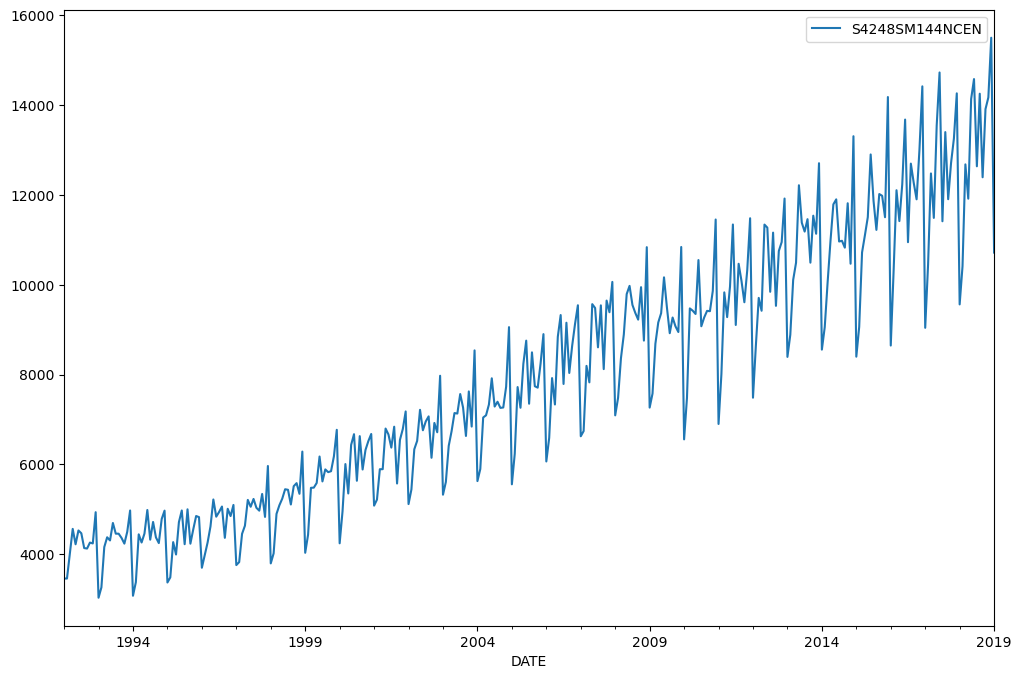

In [451]:
df.plot(figsize=(12,8))

In [452]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 325 entries, 1992-01-01 to 2019-01-01
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   S4248SM144NCEN  325 non-null    int64
dtypes: int64(1)
memory usage: 5.1 KB


In [453]:
y = df['S4248SM144NCEN'].values.astype(float)

In [454]:
test_size = 12

In [455]:
train_set = y[:-test_size]
test_set = y[-test_size:]

## Normalize the data

In the next steps we'll divide the data into train/test sets, then normalize the training values so that they fall between -1 and 1 (to improve training). We'll train the model, then predict into a period that matches the test set. Finally, we'll forecast into an unknown future.

In [456]:
from sklearn.preprocessing import MinMaxScaler

# Instantiate a scaler with a feature range from -1 to 1
scaler = MinMaxScaler(feature_range=(-1, 1))

In [457]:
# Normalize the training set
train_norm = scaler.fit_transform(train_set.reshape(-1, 1))
train_norm = torch.FloatTensor(train_norm).view(-1)

In [458]:
all_norm = scaler.fit_transform(y.reshape(-1, 1))
all_norm = torch.FloatTensor(all_norm).view(-1)

## Prepare data for LSTM
Here we'll create our list of (seq/label) tuples from the training set. Recall that an LSTM consumes a window of samples toward the first prediction, so the size of our training set will become ((325 - test_size) - window_size).

In [459]:
window_size = 12 # As it is a seasonal data

In [460]:
def input_data(seq,ws):
    out = []
    L = len(seq)
    for i in range(L-ws):
        window = seq[i:i+ws]
        label = seq[i+ws:i+ws+1]
        out.append((window,label))
    return out

In [461]:
train_data = input_data(train_norm, window_size)

In [462]:
class LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=100, out_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        
        # Add an LSTM layer:
        self.lstm = nn.LSTM(input_size,hidden_size)
        
        # Add a fully-connected layer:
        self.linear = nn.Linear(hidden_size,out_size)
        
        # Initialize h0 and c0:
        self.hidden = (torch.zeros(1,1,hidden_size),
                       torch.zeros(1,1,hidden_size))
    
    def forward(self,seq):
        lstm_out, self.hidden = self.lstm(
            seq.view(len(seq), 1, -1), self.hidden)
        pred = self.linear(lstm_out.view(len(seq),-1))
        return pred[-1]   # we only care about the last prediction

In [463]:
torch.manual_seed(42)
model = LSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [464]:
model

LSTM(
  (lstm): LSTM(1, 100)
  (linear): Linear(in_features=100, out_features=1, bias=True)
)

In [465]:
parameters_sum = 0
for p in model.parameters():
    print(p.numel())
    parameters_sum += p.numel()

print(f'------\n{parameters_sum}')

400
40000
400
400
100
1
------
41301


In [466]:
epochs = 100
future_pred_size = 12
# pred = y[-window_size:]
for i in range(epochs):

    # As we have tuple in each element in input_data, we have to unpack before we use it.
    for seq,y_train in train_data:
        optimizer.zero_grad()
        model.hidden = (torch.zeros(1,1,model.hidden_size),
                        torch.zeros(1,1,model.hidden_size))
        y_pred = model(seq)
        loss = criterion(y_train,y_pred)
        loss.backward()
        optimizer.step()

    print(f'epoch: {i+1}, loss: {loss}')

    y_future = train_norm[-window_size:].tolist()
    for i in range(future_pred_size):
        y_seq = torch.FloatTensor(y_future[-window_size:])
        with torch.no_grad():
            model.hidden = (torch.zeros(1,1,model.hidden_size),
                            torch.zeros(1,1,model.hidden_size))
            y_future.append(model(y_seq).item())

epoch: 1, loss: 0.2620842158794403
epoch: 2, loss: 0.3407169580459595
epoch: 3, loss: 0.37325239181518555
epoch: 4, loss: 0.37144577503204346
epoch: 5, loss: 0.32069429755210876
epoch: 6, loss: 0.3305143713951111
epoch: 7, loss: 0.32643330097198486
epoch: 8, loss: 0.3249703347682953
epoch: 9, loss: 0.3068375587463379
epoch: 10, loss: 0.3010624349117279
epoch: 11, loss: 0.29293522238731384
epoch: 12, loss: 0.28600311279296875
epoch: 13, loss: 0.29466763138771057
epoch: 14, loss: 0.27528876066207886
epoch: 15, loss: 0.2910611629486084
epoch: 16, loss: 0.2763768136501312
epoch: 17, loss: 0.2857084274291992
epoch: 18, loss: 0.28756067156791687
epoch: 19, loss: 0.2682710886001587
epoch: 20, loss: 0.2668357193470001
epoch: 21, loss: 0.26333165168762207
epoch: 22, loss: 0.2653818726539612
epoch: 23, loss: 0.2544768750667572
epoch: 24, loss: 0.27008354663848877
epoch: 25, loss: 0.13406023383140564
epoch: 26, loss: 2.7597239750321023e-05
epoch: 27, loss: 0.0011268437374383211
epoch: 28, loss: 6

In [467]:
x = np.arange('2018-02-01','2019-02-01',dtype = 'datetime64[M]')

In [468]:
df.index

DatetimeIndex(['1992-01-01', '1992-02-01', '1992-03-01', '1992-04-01',
               '1992-05-01', '1992-06-01', '1992-07-01', '1992-08-01',
               '1992-09-01', '1992-10-01',
               ...
               '2018-04-01', '2018-05-01', '2018-06-01', '2018-07-01',
               '2018-08-01', '2018-09-01', '2018-10-01', '2018-11-01',
               '2018-12-01', '2019-01-01'],
              dtype='datetime64[ns]', name='DATE', length=325, freq=None)

In [469]:
actual_predictions = scaler.inverse_transform(np.array(y_future[window_size:]).reshape(-1,1))

In [470]:
actual_predictions

array([[12156.69604704],
       [12715.52936128],
       [12354.64968082],
       [14322.92574415],
       [14648.70089054],
       [11343.3657338 ],
       [13058.32725334],
       [12491.24017125],
       [12813.06054211],
       [14329.45396748],
       [14740.19229385],
       [10270.97894341]])

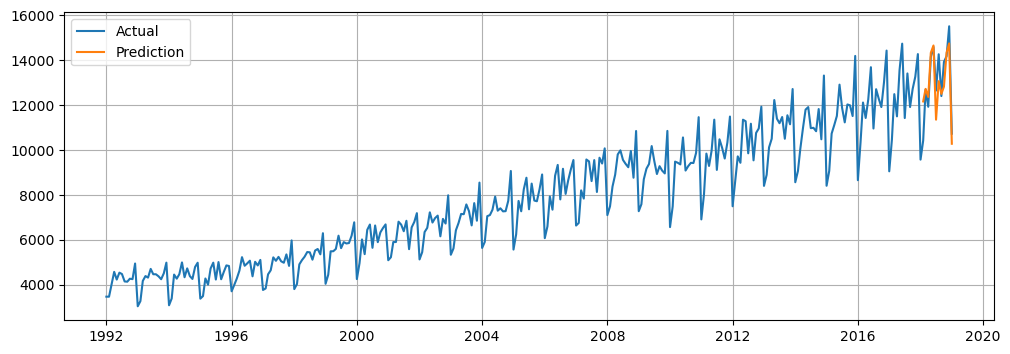

In [471]:
plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(df['S4248SM144NCEN'],label="Actual")
plt.plot(x, actual_predictions, label="Prediction")
plt.legend()
plt.show()

In [472]:
train_set[-future_pred_size:]

array([10452., 12481., 11491., 13545., 14730., 11416., 13402., 11907.,
       12711., 13261., 14265.,  9564.])

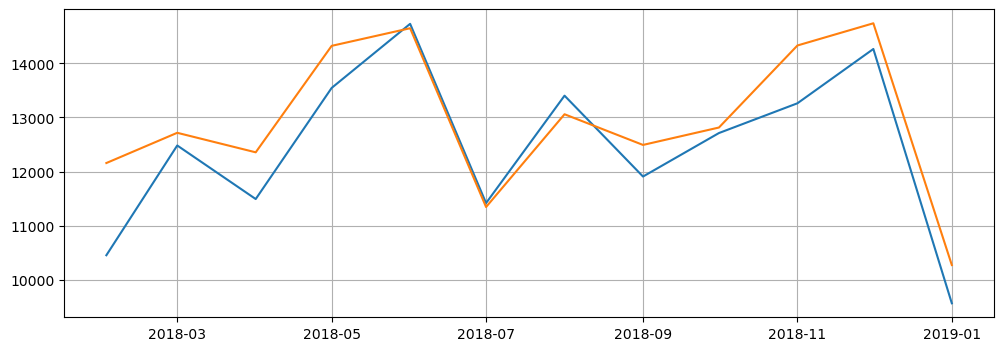

In [473]:
plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(x,train_set[-future_pred_size:])
plt.plot(x,actual_predictions)
plt.show()

## Save the model

In [474]:
torch.save(model, "RNN_Alcohol_Sales_full.pth")

## Forecasting the next year

In [475]:
epochs = 100

# set model to back to training mode
model.train()

# feature scale the entire dataset
all_data = input_data(all_norm,window_size)

import time
start_time = time.time()

for epoch in range(epochs):
    
    # train on the full set of sequences
    for seq, y_train in all_data:  
        
        # reset the parameters and hidden states
        optimizer.zero_grad()
        model.hidden = (torch.zeros(1,1,model.hidden_size),
                        torch.zeros(1,1,model.hidden_size))
        
        y_pred = model(seq)
        
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        
    # print training result
    print(f'Epoch: {epoch+1:2} Loss: {loss.item():10.8f}')
    
print(f'\nDuration: {time.time() - start_time:.0f} seconds')

Epoch:  1 Loss: 0.02535602
Epoch:  2 Loss: 0.05807330
Epoch:  3 Loss: 0.02968565
Epoch:  4 Loss: 0.01155002
Epoch:  5 Loss: 0.02538839
Epoch:  6 Loss: 0.02257419
Epoch:  7 Loss: 0.00120996
Epoch:  8 Loss: 0.00933049
Epoch:  9 Loss: 0.00506750
Epoch: 10 Loss: 0.01380948
Epoch: 11 Loss: 0.00554804
Epoch: 12 Loss: 0.00830028
Epoch: 13 Loss: 0.00013444
Epoch: 14 Loss: 0.01542223
Epoch: 15 Loss: 0.00733108
Epoch: 16 Loss: 0.00332329
Epoch: 17 Loss: 0.01082878
Epoch: 18 Loss: 0.00139746
Epoch: 19 Loss: 0.00062860
Epoch: 20 Loss: 0.00322987
Epoch: 21 Loss: 0.00029481
Epoch: 22 Loss: 0.00077115
Epoch: 23 Loss: 0.01626780
Epoch: 24 Loss: 0.04504926
Epoch: 25 Loss: 0.00115500
Epoch: 26 Loss: 0.00040433
Epoch: 27 Loss: 0.00147574
Epoch: 28 Loss: 0.00102482
Epoch: 29 Loss: 0.00013796
Epoch: 30 Loss: 0.00083705
Epoch: 31 Loss: 0.01036312
Epoch: 32 Loss: 0.02782158
Epoch: 33 Loss: 0.00334808
Epoch: 34 Loss: 0.00915591
Epoch: 35 Loss: 0.00683269
Epoch: 36 Loss: 0.00419905
Epoch: 37 Loss: 0.00016963
E

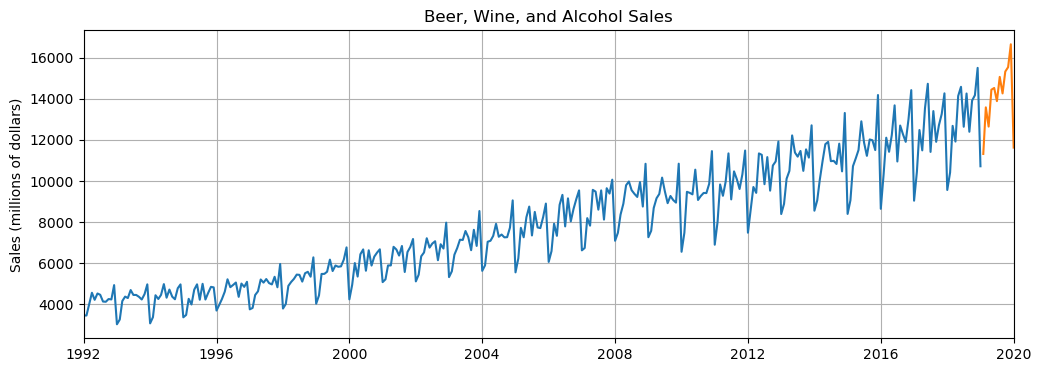

In [476]:
window_size = 12
future = 12
L = len(y)

preds = all_norm[-window_size:].tolist()

model.eval()
for i in range(future):  
    seq = torch.FloatTensor(preds[-window_size:])
    with torch.no_grad():
        # Reset the hidden parameters here!
        model.hidden = (torch.zeros(1,1,model.hidden_size),
                        torch.zeros(1,1,model.hidden_size))  
        preds.append(model(seq).item())

# Inverse-normalize the prediction set
true_predictions = scaler.inverse_transform(np.array(preds).reshape(-1, 1))

# PLOT THE RESULT
# Set a data range for the predicted data.
# Remember that the stop date has to be later than the last predicted value.
x = np.arange('2019-02-01', '2020-02-01', dtype='datetime64[M]').astype('datetime64[D]')

plt.figure(figsize=(12,4))
plt.title('Beer, Wine, and Alcohol Sales')
plt.ylabel('Sales (millions of dollars)')
plt.grid(True)
plt.autoscale(axis='x',tight=True)
plt.plot(df['S4248SM144NCEN'])
plt.plot(x,true_predictions[window_size:])
plt.show()

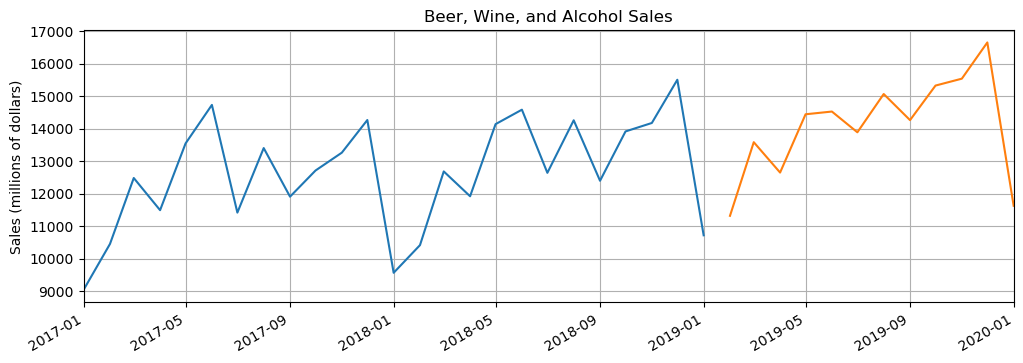

In [477]:
fig = plt.figure(figsize=(12,4))
plt.title('Beer, Wine, and Alcohol Sales')
plt.ylabel('Sales (millions of dollars)')
plt.grid(True)
plt.autoscale(axis='x',tight=True)
fig.autofmt_xdate()
plt.plot(df['S4248SM144NCEN']['2017-01-01':])
plt.plot(x,true_predictions[window_size:])
plt.show()